# 05 · Profitability: CAC, CM-LTV and LTV:CAC

The finance view. For every campaign:

```
CAC              = spend / new customers
7-day ROAS       = cohort net revenue in first 7 days / spend
90-day CM-LTV    = mean contribution margin per customer in first 90 days
LTV:CAC          = 90-day CM-LTV / CAC
90-day profit    = 90-day CM-LTV × new customers − spend
payback          = days until cumulative CM per customer ≥ CAC
```
Contribution margin = net revenue − COGS − shipping − payment fees − refunds.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from metrics import campaign_metrics, payback_days
import viz; viz.setup()
pd.set_option("display.width", 200, "display.max_columns", 50)

c = pd.read_csv("../data/processed/campaigns_virality.csv", parse_dates=["campaign_date"])
cu = pd.read_csv("../data/processed/customers.csv", parse_dates=["acquisition_date", "first_purchase_date"])
o = pd.read_csv("../data/processed/orders.csv", parse_dates=["order_date"])
cv = pd.read_csv("../data/processed/customer_value.csv", parse_dates=["acquisition_date"])

cm = campaign_metrics(c, cu, o, cv)
cm["payback_days"] = cm.campaign_id.map(payback_days(cu, o, cm))
cm.to_csv("../data/processed/campaign_metrics.csv", index=False)
MIN_COHORT = 30
big = cm[cm.new_customers >= MIN_COHORT].copy()
print(len(cm), "campaigns;", len(big), f"with ≥ {MIN_COHORT} customers")

120 campaigns; 100 with ≥ 30 customers


## 1. Portfolio scorecard

In [2]:
def pooled(d):
    n = d.new_customers.sum()
    return pd.Series({"campaigns": len(d), "spend": d.spend.sum(), "new_customers": n, "CAC": d.spend.sum() / n,
                      "ROAS_7d": d.revenue_7d.sum() / d.spend.sum(), "repeat_90d": (d.repeat_90d * d.new_customers).sum() / n,
                      "CM_LTV_90d": d.cm_90d_total.sum() / n, "LTV:CAC": d.cm_90d_total.sum() / d.spend.sum(),
                      "profit_90d": d.cm_90d_total.sum() - d.spend.sum(), "refund_rate": (d.refunds_total.sum() / d.gross_total.sum())})
score = pd.concat({"All": pooled(cm), "Non-viral": pooled(cm[cm.is_viral == 0]), "Viral": pooled(cm[cm.is_viral == 1])}, axis=1)
score.round(2)

,All,Non-viral,Viral
campaigns,120.00,112.00,8.00
spend,1696863.52,1424632.66,272230.86
new_customers,40947.00,31808.00,9139.00
CAC,41.44,44.79,29.79
ROAS_7d,2.05,1.88,2.95
repeat_90d,0.40,0.42,0.36
CM_LTV_90d,57.15,57.97,54.30
LTV:CAC,1.38,1.29,1.82
profit_90d,643182.72,419126.49,224056.23
refund_rate,0.10,0.10,0.09


Pooled, the viral campaigns deliver a **better LTV:CAC than the non-viral campaigns** because their CAC is so
much lower, even though each viral customer is worth slightly less. (The four "high reach, low sharing"
campaigns do better still — large distribution without the share-driven audience.) The rest of this notebook
shows why the pooled number hides the real decision.

## 2. The chart that tells the story: virality vs customer value

x = virality score, y = 90-day CM-LTV per customer, bubble = customers acquired.

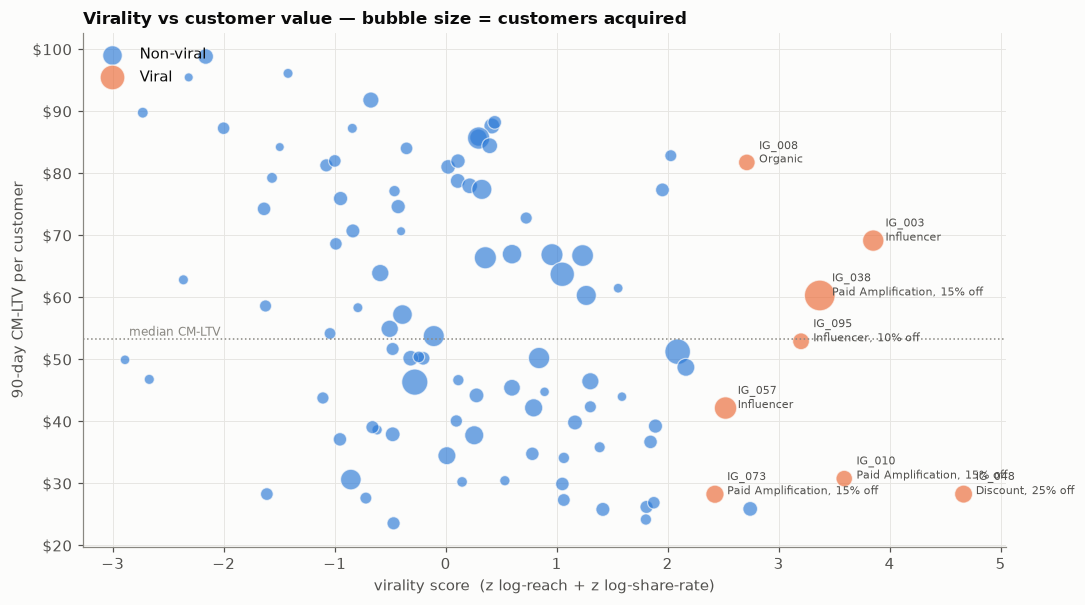

Spearman(virality score, CM-LTV 90d) = -0.35


In [3]:
fig, ax = plt.subplots(figsize=(10, 5.6))
for flag, col, lbl in [(0, viz.NONVIRAL, "Non-viral"), (1, viz.VIRAL, "Viral")]:
    d = big[big.is_viral == flag]
    ax.scatter(d.virality_score, d.cm_90d_per_customer, s=np.sqrt(d.new_customers) * 6, color=col, alpha=0.65, label=lbl, edgecolor=viz.SURFACE, linewidth=0.8)
for _, r in big[big.is_viral == 1].iterrows():
    ax.annotate(f"{r.campaign_id}\n{r.campaign_type}, {r.discount_pct:.0f}% off" if r.discount_pct else f"{r.campaign_id}\n{r.campaign_type}",
                (r.virality_score, r.cm_90d_per_customer), fontsize=7, xytext=(8, 0), textcoords="offset points", color=viz.INK2)
ax.axhline(big.cm_90d_per_customer.median(), color=viz.MUTED, linestyle=":", linewidth=1)
ax.text(big.virality_score.min(), big.cm_90d_per_customer.median(), " median CM-LTV", fontsize=8, color=viz.MUTED, va="bottom")
ax.yaxis.set_major_formatter(FuncFormatter(viz.money)); ax.set_xlabel("virality score  (z log-reach + z log-share-rate)"); ax.set_ylabel("90-day CM-LTV per customer")
ax.set_title("Virality vs customer value — bubble size = customers acquired"); ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig("../images/05_virality_vs_ltv.png"); plt.show()
print("Spearman(virality score, CM-LTV 90d) = %.2f" % big[["virality_score", "cm_90d_per_customer"]].corr("spearman").iloc[0, 1])

## 3. LTV:CAC by campaign

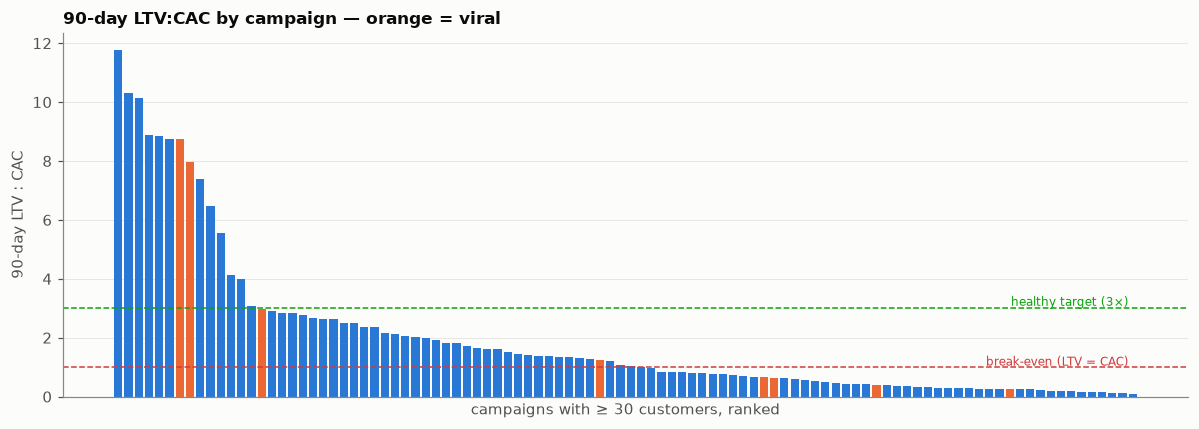

share of campaigns below break-even at 90 days: 48%   (viral: 50%, non-viral: 48%)


In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
d = big.sort_values("ltv_cac", ascending=False).reset_index(drop=True)
ax.bar(d.index, d.ltv_cac, color=[viz.VIRAL if v else viz.NONVIRAL for v in d.is_viral], width=0.8)
ax.axhline(1, color=viz.BAD, linewidth=1, linestyle="--"); ax.text(len(d) - 1, 1.05, "break-even (LTV = CAC) ", ha="right", fontsize=8, color=viz.BAD)
ax.axhline(3, color=viz.GOOD, linewidth=1, linestyle="--"); ax.text(len(d) - 1, 3.08, "healthy target (3×) ", ha="right", fontsize=8, color=viz.GOOD)
ax.set_xticks([]); ax.set_xlabel(f"campaigns with ≥ {MIN_COHORT} customers, ranked"); ax.set_ylabel("90-day LTV : CAC")
ax.set_title("90-day LTV:CAC by campaign — orange = viral"); ax.set_ylim(0, min(d.ltv_cac.max() * 1.05, 15))
plt.tight_layout(); plt.savefig("../images/05_ltv_cac_ranked.png"); plt.show()
print(f"share of campaigns below break-even at 90 days: {(big.ltv_cac < 1).mean():.0%}   (viral: {(big[big.is_viral==1].ltv_cac < 1).mean():.0%}, non-viral: {(big[big.is_viral==0].ltv_cac < 1).mean():.0%})")

## 4. Campaign A vs B vs C — the CFO/CMO conversation

- **A** — the most-shared campaign of the year (viral by any definition).
- **B** — the campaign with the best 90-day economics.
- **C** — the viral campaign with the best 90-day economics: proof that virality and value are not opposites.

In [5]:
A = big[big.is_viral == 1].sort_values("share_rate", ascending=False).iloc[0]
B = big.sort_values("ltv_cac", ascending=False).iloc[0]
C = big[big.is_viral == 1].sort_values("ltv_cac", ascending=False).iloc[0]
cols = ["campaign_id", "campaign_type", "content_type", "creator_tier", "discount_pct", "reach", "shares", "share_rate", "save_rate", "spend",
        "new_customers", "revenue_7d", "roas_7d", "cac", "avg_first_order", "repeat_90d", "cm_90d_per_customer", "ltv_cac", "campaign_profit_90d", "payback_days"]
pd.DataFrame({"A · most shared (viral)": A[cols], "B · best economics": B[cols], "C · viral AND valuable": C[cols]}).round(3)

,A · most shared (viral),B · best economics,C · viral AND valuable
campaign_id,IG_048,IG_039,IG_038
campaign_type,Discount,Influencer,Paid Amplification
content_type,Reel,Reel,Carousel
creator_tier,Brand,Mid,Brand
discount_pct,25,15,15
reach,3386549,1683594,4143880
shares,145458,7366,63127
share_rate,0.042952,0.004375,0.015234
save_rate,0.003241,0.016476,0.020814
spend,11922.41,9718.99,31227.49


## 5. Where does the money go vs where does the value come from?

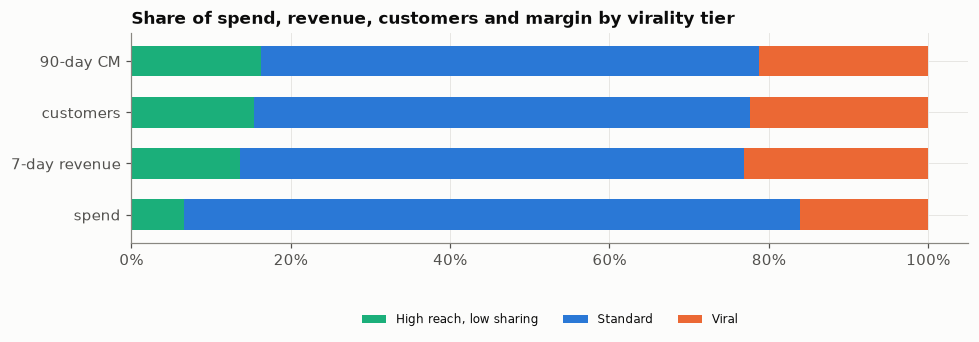

,spend,customers,cm90,rev7
virality_tier,,,,
"High reach, low sharing",0.066,0.154,0.163,0.136
Standard,0.774,0.623,0.625,0.633
Viral,0.160,0.223,0.212,0.231


In [6]:
share = cm.groupby("virality_tier").agg(spend=("spend", "sum"), customers=("new_customers", "sum"), cm90=("cm_90d_total", "sum"), rev7=("revenue_7d", "sum"))
share = share / share.sum()
fig, ax = plt.subplots(figsize=(9, 3.6))
share[["spend", "rev7", "customers", "cm90"]].rename(columns={"rev7": "7-day revenue", "cm90": "90-day CM"}).T.plot.barh(
    stacked=True, ax=ax, color=[viz.SERIES[2], viz.NONVIRAL, viz.VIRAL], width=0.6)
ax.xaxis.set_major_formatter(FuncFormatter(viz.pct)); ax.set_title("Share of spend, revenue, customers and margin by virality tier"); ax.legend(ncol=3, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.45))
plt.tight_layout(); plt.savefig("../images/05_share_by_tier.png"); plt.show()
share.round(3)

## 6. Payback period

campaigns paying back within 180 days: 53 of 100  (53%)
           count  mean  50%    max
is_viral                          
Non-viral   49.0  17.3  0.0  114.0
Viral        4.0  11.2  0.0   45.0


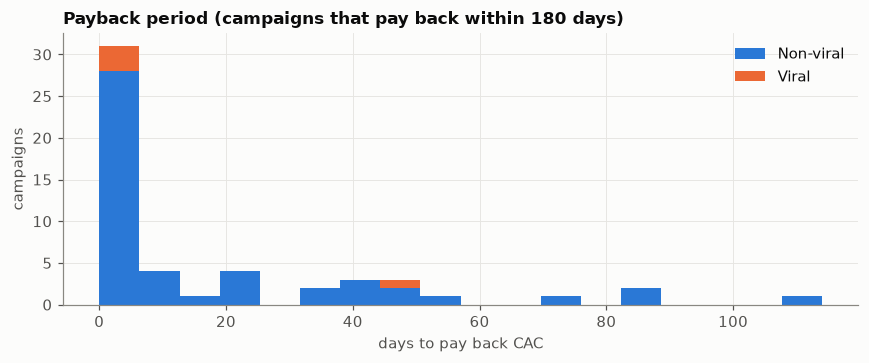

In [7]:
pb = big.dropna(subset=["payback_days"])
print(f"campaigns paying back within 180 days: {len(pb)} of {len(big)}  ({len(pb)/len(big):.0%})")
print(big.groupby("is_viral").payback_days.describe()[["count", "mean", "50%", "max"]].rename(index={0: "Non-viral", 1: "Viral"}).round(1))
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist([pb[pb.is_viral == 0].payback_days, pb[pb.is_viral == 1].payback_days], bins=18, color=[viz.NONVIRAL, viz.VIRAL], label=["Non-viral", "Viral"], stacked=True)
ax.set_xlabel("days to pay back CAC"); ax.set_ylabel("campaigns"); ax.set_title("Payback period (campaigns that pay back within 180 days)"); ax.legend()
plt.tight_layout(); plt.savefig("../images/05_payback.png"); plt.show()

## 7. Refunds and discounts erode LTV

Spearman(discount_rate, CM-LTV) = -0.70
Spearman(refund_rate, CM-LTV) = 0.03


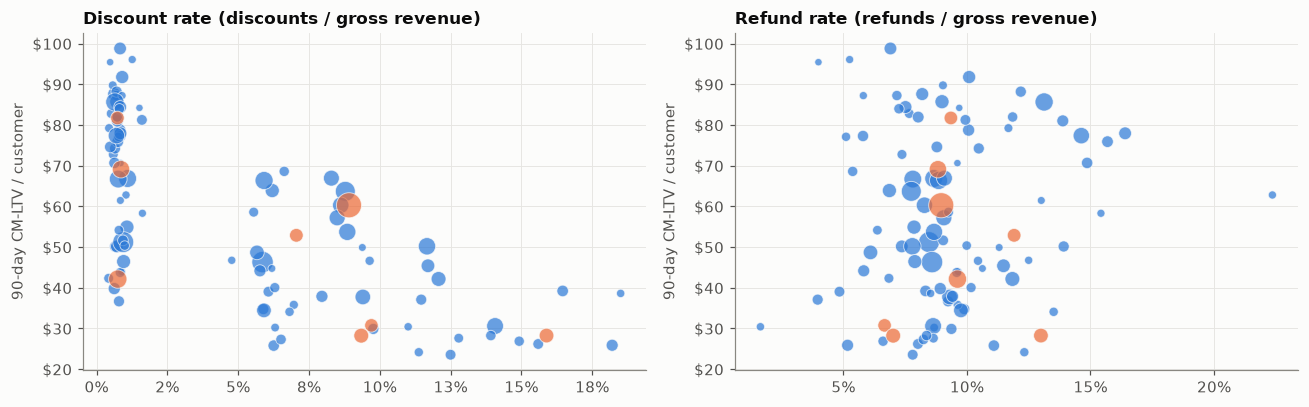

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for a, xcol, ttl in [(ax[0], "discount_rate", "Discount rate (discounts / gross revenue)"), (ax[1], "refund_rate", "Refund rate (refunds / gross revenue)")]:
    for flag, col in [(0, viz.NONVIRAL), (1, viz.VIRAL)]:
        d = big[big.is_viral == flag]
        a.scatter(d[xcol], d.cm_90d_per_customer, s=np.sqrt(d.new_customers) * 4, color=col, alpha=0.7, edgecolor=viz.SURFACE, linewidth=0.6)
    a.xaxis.set_major_formatter(FuncFormatter(viz.pct)); a.yaxis.set_major_formatter(FuncFormatter(viz.money)); a.set_title(ttl); a.set_ylabel("90-day CM-LTV / customer")
    print(f"Spearman({xcol}, CM-LTV) = {big[[xcol, 'cm_90d_per_customer']].corr('spearman').iloc[0, 1]:.2f}")
plt.tight_layout(); plt.savefig("../images/05_discount_refund_vs_ltv.png"); plt.show()

## 8. Which kinds of campaigns earn their budget?

In [9]:
by_type = cm.groupby("campaign_type").apply(pooled).T.round(2)
by_type.loc[["spend", "new_customers", "CAC", "ROAS_7d", "repeat_90d", "CM_LTV_90d", "LTV:CAC", "profit_90d"]]

campaign_type,Discount,Influencer,Organic,Paid Amplification,Product Drop,UGC
spend,138550.12,639248.35,46585.22,648380.37,131508.73,92590.73
new_customers,4858.00,12812.00,1558.00,14950.00,4572.00,2197.00
CAC,28.52,49.89,29.90,43.37,28.76,42.14
ROAS_7d,2.78,1.62,3.64,1.86,3.99,1.75
repeat_90d,0.29,0.39,0.46,0.41,0.53,0.43
CM_LTV_90d,36.85,56.28,75.48,55.65,78.80,59.23
LTV:CAC,1.29,1.13,2.52,1.28,2.74,1.41
profit_90d,40457.98,81824.28,71014.77,183579.31,228763.25,37543.13


In [10]:
by_tier = cm.groupby("creator_tier").apply(pooled).T.round(2)
by_tier.loc[["spend", "new_customers", "CAC", "ROAS_7d", "repeat_90d", "CM_LTV_90d", "LTV:CAC", "profit_90d"]]

creator_tier,Brand,Macro,Mega,Micro,Mid,Nano
spend,965024.44,229433.85,162576.63,95606.94,208212.44,36009.22
new_customers,25938.00,2178.00,3673.00,2702.00,6395.00,61.00
CAC,37.21,105.34,44.26,35.38,32.56,590.32
ROAS_7d,2.37,0.93,1.42,2.31,2.52,0.16
repeat_90d,0.41,0.32,0.36,0.46,0.42,0.34
CM_LTV_90d,57.40,60.00,44.85,61.30,60.49,54.53
LTV:CAC,1.54,0.57,1.01,1.73,1.86,0.09
profit_90d,523815.31,-98744.65,2140.44,70024.75,178629.57,-32682.70


In [11]:
cm["discount_band"] = pd.cut(cm.discount_pct, [-1, 0, 15, 30], labels=["no discount", "10–15%", "20–30%"])
by_disc = cm.groupby("discount_band").apply(pooled).T.round(2)
by_disc.loc[["spend", "new_customers", "CAC", "ROAS_7d", "repeat_90d", "CM_LTV_90d", "LTV:CAC", "profit_90d"]]

discount_band,no discount,10–15%,20–30%
spend,800311.29,758002.11,138550.12
new_customers,17121.00,18968.00,4858.00
CAC,46.74,39.96,28.52
ROAS_7d,1.99,1.98,2.78
repeat_90d,0.47,0.38,0.29
CM_LTV_90d,67.32,53.17,36.85
LTV:CAC,1.44,1.33,1.29
profit_90d,352239.28,250485.46,40457.98


## 9. Budget reallocation scenario (illustrative)

What if the bottom-quartile LTV:CAC campaigns (by spend) had not run, and their budget had gone to campaigns
with the profile of the top quartile at the *same CAC*? This assumes CAC does not rise with scale, which is
optimistic; treat it as an upper bound on the opportunity, not a forecast.

In [12]:
q1, q3 = big.ltv_cac.quantile([0.25, 0.75])
bottom, top = big[big.ltv_cac <= q1], big[big.ltv_cac >= q3]
moved = bottom.spend.sum()
top_cac = top.spend.sum() / top.new_customers.sum()
top_ltv = top.cm_90d_total.sum() / top.new_customers.sum()
print(f"bottom-quartile campaigns: {len(bottom)}, spend ${moved:,.0f}, 90-day CM ${bottom.cm_90d_total.sum():,.0f}, profit ${bottom.campaign_profit_90d.sum():,.0f}")
print(f"same budget at top-quartile profile (CAC ${top_cac:.0f}, CM-LTV ${top_ltv:.0f}): customers {moved / top_cac:,.0f}, 90-day CM ${moved / top_cac * top_ltv:,.0f}, profit ${moved / top_cac * top_ltv - moved:,.0f}")
print(f"of the bottom quartile, {bottom.is_viral.sum()} are viral; of the top quartile, {top.is_viral.sum()} are viral")

bottom-quartile campaigns: 25, spend $541,128, 90-day CM $122,696, profit $-418,431
same budget at top-quartile profile (CAC $13, CM-LTV $63): customers 42,319, 90-day CM $2,680,938, profit $2,139,810
of the bottom quartile, 1 are viral; of the top quartile, 3 are viral


**Takeaways.**
- Pooled, viral campaigns beat non-viral campaigns on LTV:CAC — driven by cheap acquisition at scale, not by
  better customers (their 90-day CM-LTV per customer is lower).
- At campaign level the virality score is *negatively* correlated with 90-day CM-LTV, but viral campaigns are
  spread across the full value range (from the bottom decile to the top). Notebook 06 shows the negative
  correlation is carried by share rate and discounts, not by reach.
- Discount depth is the strongest single drag on customer value; the bottom LTV:CAC quartile is dominated by
  heavy-discount and macro/mega creator campaigns. Refund rate varies little between campaigns here.
- Roughly half of all campaigns have not paid back at 90 days — the budget problem is real, and it is not a
  viral-vs-non-viral problem.